# 01 — EDA & Preprocessing

**Goal:** load the raw climate-stance tweet dataset, sanity-check it, engineer features used for later error analysis, clean the text, and create stratified train/val/test splits.

**Outputs:** `data/processed/{train,val,test}.parquet`, plots in `results/figures/eda/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import (
    add_features,
    clean_tweet,
    load_raw,
    make_splits,
    save_splits,
)

FIG_DIR = PROJECT_ROOT / 'results' / 'figures' / 'eda'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

## 1. Load and sanity-check

In [2]:
df = load_raw()
print(f'rows: {len(df):,}')
print(f'columns: {list(df.columns)}')
df.head()

rows: 99,993
columns: ['id', 'text', 'likes', 'retweets', 'stance']


,id,text,likes,retweets,stance
0,1202419442971369472,Trump Adviser William Happer Talks Climate Ala...,0.0,0.0,sceptic
1,1586366032150638592,@sAhz2jB4oDnFrN7vlQTjOQ #ClimateHoax,1.0,0.0,sceptic
2,1490648918824210436,Let’s just call it climate change so whichever...,42.0,14.0,sceptic
3,1207980833447055365,#EndTheUN NOW! #GlobalGovernment via this Barr...,1.0,0.0,sceptic
4,1552768417282887681,@g86w2IIt5siaqKQ_HSPN8g Are you talking about ...,3.0,1.0,sceptic


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 99993 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        99993 non-null  str    
 1   text      99993 non-null  str    
 2   likes     99985 non-null  float64
 3   retweets  99975 non-null  float64
 4   stance    99993 non-null  str    
dtypes: float64(2), str(3)
memory usage: 28.3 MB


In [4]:
print('Stance distribution:')
print(df['stance'].value_counts())
print()
print('Class proportions:')
print(df['stance'].value_counts(normalize=True).round(4))

Stance distribution:
stance
activist    50000
sceptic     49993
Name: count, dtype: int64

Class proportions:
stance
activist    0.5
sceptic     0.5
Name: proportion, dtype: float64


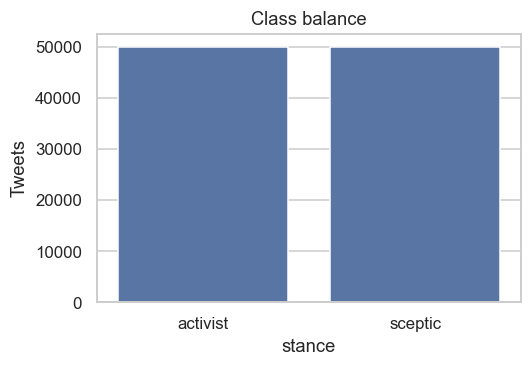

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df, x='stance', order=['activist', 'sceptic'], ax=ax)
ax.set_title('Class balance')
ax.set_ylabel('Tweets')
plt.tight_layout()
plt.savefig(FIG_DIR / 'class_balance.png', bbox_inches='tight')
plt.show()

## 2. Engineered features (used for error analysis later)

In [6]:
df = add_features(df)
df[['raw_len', 'n_hashtags', 'n_mentions', 'n_urls', 'has_emoji']].describe().round(2)

,raw_len,n_hashtags,n_mentions,n_urls
count,99993.00,99993.00,99993.00,99993.00
mean,219.89,3.55,2.14,0.90
std,184.99,3.17,7.21,0.61
min,12.00,0.00,0.00,0.00
25%,132.00,1.00,0.00,1.00
50%,199.00,3.00,1.00,1.00
75%,275.00,5.00,1.00,1.00
max,1516.00,29.00,50.00,8.00


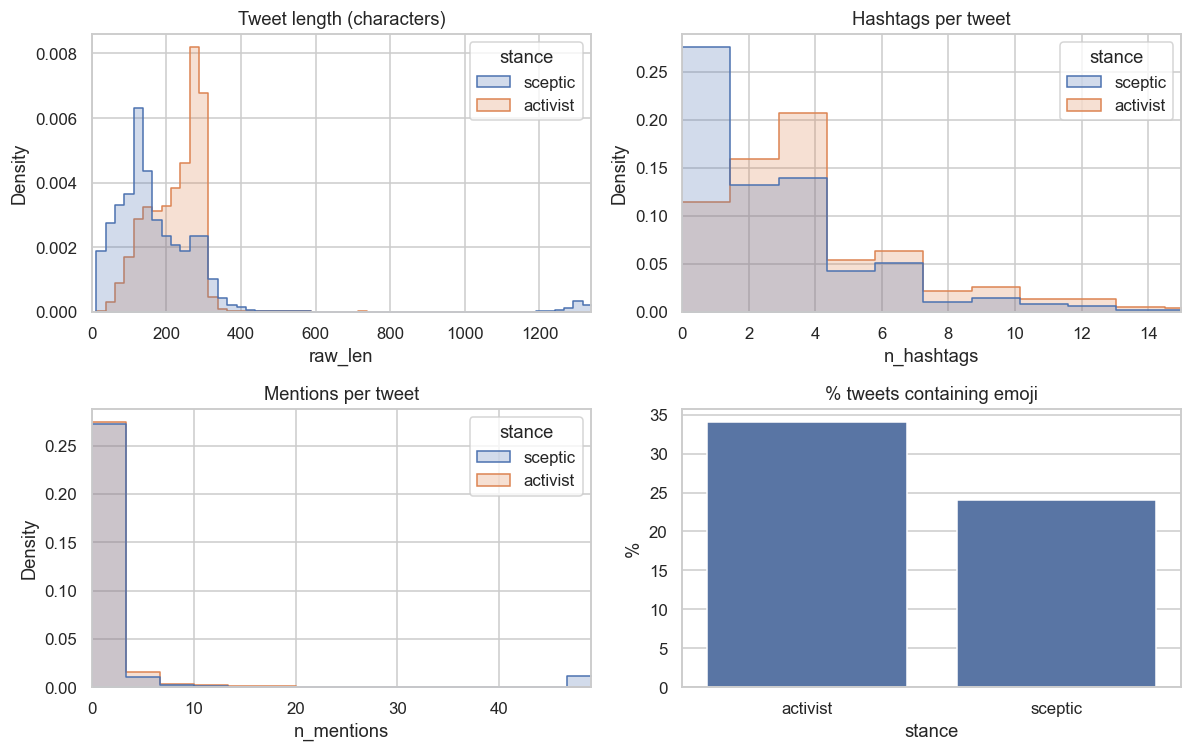

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(data=df, x='raw_len', hue='stance', bins=60, element='step',
             stat='density', common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title('Tweet length (characters)')
axes[0, 0].set_xlim(0, df['raw_len'].quantile(0.99))

sns.histplot(data=df, x='n_hashtags', hue='stance', bins=20, element='step',
             stat='density', common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title('Hashtags per tweet')
axes[0, 1].set_xlim(0, df['n_hashtags'].quantile(0.99))

sns.histplot(data=df, x='n_mentions', hue='stance', bins=15, element='step',
             stat='density', common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title('Mentions per tweet')
axes[1, 0].set_xlim(0, df['n_mentions'].quantile(0.99))

emoji_pct = (df.groupby('stance')['has_emoji'].mean() * 100).round(2)
sns.barplot(x=emoji_pct.index, y=emoji_pct.values, ax=axes[1, 1])
axes[1, 1].set_title('% tweets containing emoji')
axes[1, 1].set_ylabel('%')

plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_distributions.png', bbox_inches='tight')
plt.show()

In [8]:
print('Mean engagement (likes + retweets) per stance:')
engagement = df['likes'].fillna(0) + df['retweets'].fillna(0)
df_e = df.assign(engagement=engagement)
print(df_e.groupby('stance')['engagement'].agg(['mean', 'median', 'std']).round(2))

Mean engagement (likes + retweets) per stance:
           mean  median     std
stance                         
activist  12.20     2.0  218.68
sceptic    4.41     0.0  107.37


## 3. Cleaning

Hashtags **must** be removed: stance labels were derived from hashtags in the original dataset, so leaving them in inflates accuracy unfairly. URLs and @mentions are stripped (no semantic content for stance). Emojis are dropped for the main pipeline (we keep `has_emoji` as a separate feature for error analysis).

In [9]:
df['clean_text'] = df['text'].apply(clean_tweet)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f'After cleaning + dropping empties: {len(df):,} tweets')
print()
print('Sample cleaned tweets:')
for stance in ['activist', 'sceptic']:
    print(f'\n--- {stance} ---')
    sample = df[df['stance'] == stance].sample(3, random_state=0)
    for _, row in sample.iterrows():
        print(f'  RAW:   {row["text"][:120]}')
        print(f'  CLEAN: {row["clean_text"][:120]}')
        print()

After cleaning + dropping empties: 92,873 tweets

Sample cleaned tweets:

--- activist ---
  RAW:   Chifundo from #Malawi and Kathy in #Scotland live on our Youth Festival Facebook webinar hearing from musician Jo Kellz 
  CLEAN: chifundo from and kathy in live on our youth festival facebook webinar hearing from musician jo kellz about his brillian

  RAW:   This is awesome. State policies to move to clean energy work, and a federal policy will work even better (nature of the 
  CLEAN: this is awesome state policies to move to clean energy work and a federal policy will work even better nature of the gri

  RAW:   WOW so inspiring #MustWatch 

New Story Run https://t.co/GPJaGHyWb2

“Tackle the climate crisis in a way that makes you 
  CLEAN: wow so inspiring new story run tackle the climate crisis in a way that makes you feel most alive runs from cumbria to mo


--- sceptic ---
  RAW:   @YoW6qbxDOFz9lRtsJHDsRQ House that GAS stove in your kitchen?  Ms. #climateHoax Hypocrite 

#cdnpoli

Cleaned tweet length (words) — describe:
count    92873.00
mean        20.12
std         11.84
min          1.00
25%         11.00
50%         18.00
75%         29.00
max         75.00
Name: clean_len, dtype: float64


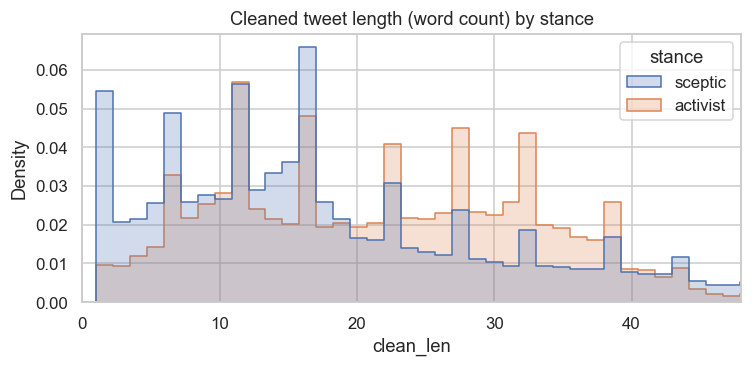

In [10]:
df['clean_len'] = df['clean_text'].str.split().str.len()
print('Cleaned tweet length (words) — describe:')
print(df['clean_len'].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(data=df, x='clean_len', hue='stance', bins=60, element='step',
             stat='density', common_norm=False, ax=ax)
ax.set_xlim(0, df['clean_len'].quantile(0.99))
ax.set_title('Cleaned tweet length (word count) by stance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cleaned_length.png', bbox_inches='tight')
plt.show()

## 4. Stratified 80/10/10 split

In [11]:
train, val, test = make_splits(df, test_size=0.10, val_size=0.10, seed=42)
for name, split in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:<5}  n={len(split):>6,}  '
          f'activist={split["stance"].value_counts(normalize=True).get("activist", 0):.4f}  '
          f'sceptic={split["stance"].value_counts(normalize=True).get("sceptic", 0):.4f}')

train  n=74,297  activist=0.5383  sceptic=0.4617
val    n= 9,288  activist=0.5383  sceptic=0.4617
test   n= 9,288  activist=0.5383  sceptic=0.4617


In [12]:
save_splits(train, val, test)
print('Saved to data/processed/')
for p in (PROJECT_ROOT / 'data' / 'processed').glob('*.parquet'):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

Saved to data/processed/
  train.parquet  (19341.9 KB)
  test.parquet  (2447.5 KB)
  val.parquet  (2433.4 KB)


## 5. Sanity-check the saved splits

In [13]:
from src.data import load_splits
tr, va, te = load_splits()
print(f'reloaded shapes: train={tr.shape}, val={va.shape}, test={te.shape}')
print(f'columns: {list(tr.columns)}')
tr.head(3)

reloaded shapes: train=(74297, 12), val=(9288, 12), test=(9288, 12)
columns: ['id', 'text', 'likes', 'retweets', 'stance', 'raw_len', 'n_hashtags', 'n_mentions', 'n_urls', 'has_emoji', 'clean_text', 'clean_len']


,id,text,likes,retweets,stance,raw_len,n_hashtags,n_mentions,n_urls,has_emoji,clean_text,clean_len
0,1608941557767639040,#ClimateHoax never gets a holiday. \nFollow t...,0.0,0.0,sceptic,78,1,0,1,False,never gets a holiday follow the money,7
1,1184076634535542784,Interesting reading. #ClimateAction #ClimateC...,0.0,0.0,sceptic,104,4,0,1,False,interesting reading,2
2,1363590657768640521,@eNzvd9K6KR9MATIft5VZQg So happy to let everyo...,0.0,0.0,sceptic,205,3,1,0,False,so happy to let everyone else tell us how to d...,28
